# Genre Distribution

Donut chart of genre share across the corpus. Labels and percentages sit outside the wedges with leader lines, so every slice is readable regardless of size.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

genres = [
    "Techno",
    "Disco / Funk",
    "Rock / Punk",
    "Tech House",
    "Hip-Hop",
    "Progressive",
    "Deep House",
    "Drum & Bass",
    "Trance",
    "Electro",
]
percentages = [35.6, 18.3, 10.9, 10.5, 6.2, 5.2, 4.4, 3.6, 3.4, 2.1]

palette = [
    "#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51",
    "#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500",
]

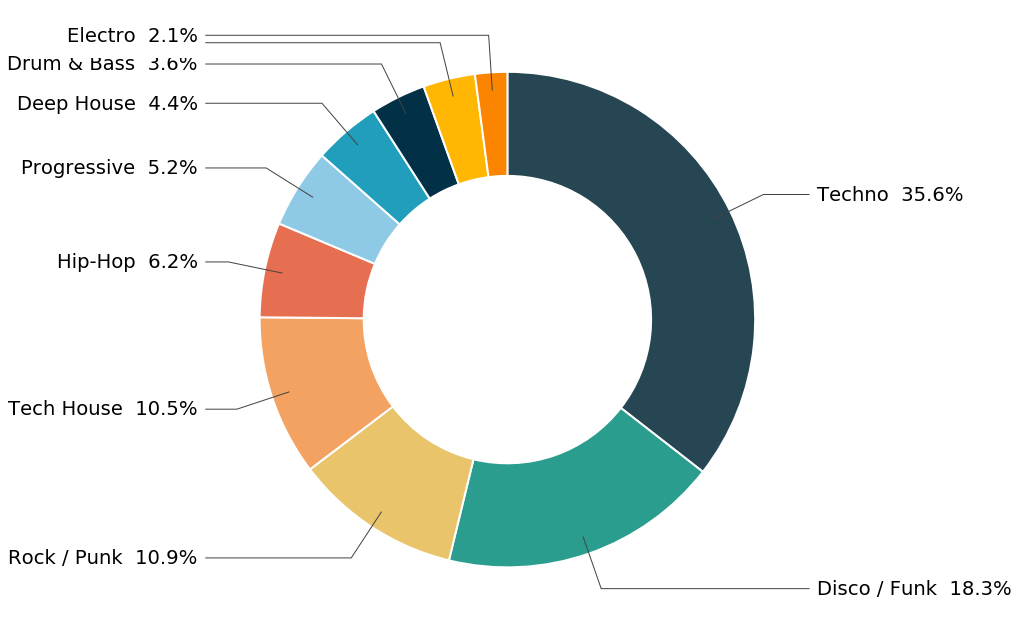

In [2]:
font_scale = 1.4

fig, ax = plt.subplots(figsize=(12, 9))
wedges, _ = ax.pie(
    percentages,
    colors=palette,
    startangle=90,
    counterclock=False,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 2},
)

label_kw = dict(arrowprops=dict(arrowstyle="-", color="#444444", lw=1),
                bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="none"),
                zorder=5, va="center", fontsize=14 * font_scale)

for w, genre, pct in zip(wedges, genres, percentages):
    angle = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    horiz = "right" if x < 0 else "left"
    connection = f"angle,angleA=0,angleB={angle}"
    label_kw["arrowprops"]["connectionstyle"] = connection
    ax.annotate(
        f"{genre}  {pct:.1f}%",
        xy=(x * 0.92, y * 0.92),
        xytext=(1.25 * np.sign(x), 1.15 * y),
        ha=horiz,
        **label_kw,
    )

ax.set(aspect="equal")
plt.tight_layout()
plt.savefig("genre_distribution.png", dpi=200, bbox_inches="tight")
plt.show()